In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import plot_tree
from sklearn.model_selection import learning_curve


In [ ]:
# LOADING AND SPLITTING 

print("Loading Data...")
# Ensure the file 'business+economy.csv' is in the same directory

filename = 'business+economy.csv'
folder = 'data'

csv_filep = os.path.join(os.getcwd(), folder, filename)

df = pd.read_csv(csv_filep)

# Drop unnecessary columns
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df = df.drop(columns=['flight']) # Drop ID column

X = df.drop(columns=['price'])
y_continuous = df['price']

# SPLIT DATA FIRST (Prevents Leakage)
print("Splitting Data...")
X_train, X_test, y_train_cont, y_test_cont = train_test_split(
    X, y_continuous, test_size=0.2, random_state=17
)

print(f"Training Set Size: {X_train.shape[0]} rows")
print(f"Testing Set Size:  {X_test.shape[0]} rows")

# FEATURE ENGINEERING

# Calculate quantile bins based ONLY on training data prices
print("\nCreating Target Classes (Binning)...")
train_labels = ['Low', 'Medium', 'High']

# qcut returns the discretized data and the bins used
y_train, bins = pd.qcut(y_train_cont, q=3, labels=train_labels, retbins=True)

# Apply those specific training bins to the test set
# We use pd.cut (not qcut) for the test set because the bins are fixed
y_test = pd.cut(y_test_cont, bins=bins, labels=train_labels, include_lowest=True)


if y_test.isnull().sum() > 0:
    print(f"Warning: {y_test.isnull().sum()} items in test set were out of training price range. Filling with mode.")
    y_test = y_test.fillna(y_train.mode()[0])

print("Encoding Categorical Features...")
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

ohe = preprocessor.named_transformers_['cat']

# Get the one-hot encoded feature names
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)

numerical_feature_names = [col for col in X_train.columns if col not in categorical_cols]


all_feature_names = list(ohe_feature_names) + numerical_feature_names
X_train_final = pd.DataFrame(X_train_encoded, columns=all_feature_names)
X_test_final = pd.DataFrame(X_test_encoded, columns=all_feature_names)

Loading Data...
Splitting Data...
Training Set Size: 240122 rows
Testing Set Size:  60031 rows

Creating Target Classes (Binning)...
Encoding Categorical Features...


In [ ]:
# DEFAULT MODEL 

print("\n" + "="*40)
print("PHASE 1: Training Default Model...")
print("="*40)

rf = RandomForestClassifier(random_state=17, n_jobs=-1)
rf.fit(X_train_final, y_train)

# Evaluate
y_pred = rf.predict(X_test_final)
acc = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


PHASE 1: Training Default Model...
Model Accuracy: 0.9525

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.97      0.98     20103
         Low       0.94      0.96      0.95     19926
      Medium       0.93      0.93      0.93     20002

    accuracy                           0.95     60031
   macro avg       0.95      0.95      0.95     60031
weighted avg       0.95      0.95      0.95     60031



In [ ]:
# HYPERPARAMETER TUNING
print("\n" + "="*40)
print("PHASE 2: Running GridSearchCV...")
print("="*40)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 25],
    'min_samples_leaf': [2, 5],
    'min_samples_split': [2, 5]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=17, n_jobs=-1),
    param_grid=param_grid,
    cv=3,                   
    scoring='accuracy',
    n_jobs=-1,              
    verbose=1             
)

# Fit on the encoded training data
grid_search.fit(X_train_final, y_train)

# Get the best model
rf_optimized = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")

# Evaluate Optimized Model
y_pred_optimized = rf_optimized.predict(X_test_final)
optimized_acc = accuracy_score(y_test, y_pred_optimized)

print(f"Optimized Model Accuracy: {optimized_acc:.4f}")
print("\nOptimized Model Classification Report:")
print(classification_report(y_test, y_pred_optimized))


PHASE 2: Running GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters Found: {'max_depth': 25, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Optimized Model Accuracy: 0.9532

Optimized Model Classification Report:
              precision    recall  f1-score   support

        High       0.99      0.96      0.98     20103
         Low       0.94      0.97      0.95     19926
      Medium       0.93      0.93      0.93     20002

    accuracy                           0.95     60031
   macro avg       0.95      0.95      0.95     60031
weighted avg       0.95      0.95      0.95     60031



In [ ]:
print("\n" + "="*40)
print("SUMMARY OF IMPROVEMENT")
print("="*40)

improvement = (optimized_acc - acc) * 100 
print(f"Default Accuracy:   {acc:.4f}")
print(f"Optimized Accuracy: {optimized_acc:.4f}")
print(f"Net Improvement:    {improvement:.2f}%")


SUMMARY OF IMPROVEMENT
Default Accuracy:   0.9525
Optimized Accuracy: 0.9532
Net Improvement:    0.07%



Confusion Matrix:
          Low  Medium   High
Low     19268     654      4
Medium   1238   18610    154
High       23     736  19344


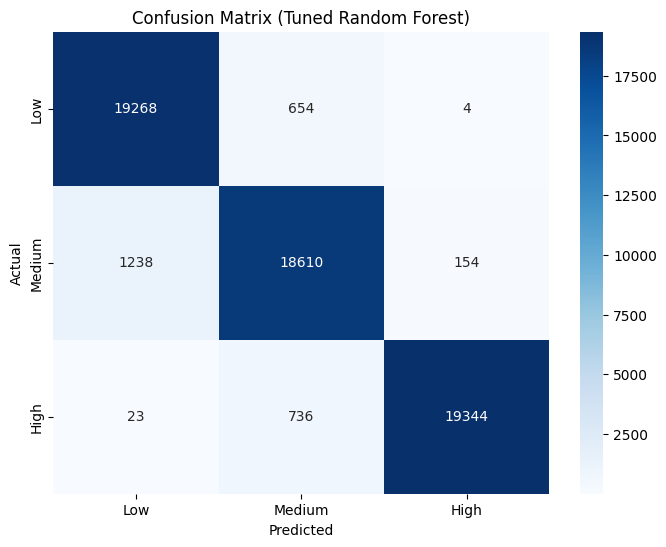


Feature Importances:
                         Feature  Importance
27                 class_Economy    0.456035
29                     days_left    0.162733
28                      duration    0.105354
4                airline_Vistara    0.044587
0              airline_Air_India    0.022049
2                 airline_Indigo    0.017356
8            source_city_Kolkata    0.015524
25      destination_city_Kolkata    0.014916
15             stops_two_or_more    0.013722
16                    stops_zero    0.013709
1               airline_GO_FIRST    0.012762
24    destination_city_Hyderabad    0.011116
9             source_city_Mumbai    0.010728
7          source_city_Hyderabad    0.010541
6              source_city_Delhi    0.010146
23        destination_city_Delhi    0.009271
26       destination_city_Mumbai    0.009113
5            source_city_Chennai    0.007523
22      destination_city_Chennai    0.007488
13        departure_time_Morning    0.005703
18          arrival_time_Evening 

C:\Users\Yip Mun Jun\AppData\Local\Temp\ipykernel_11456\63721020.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


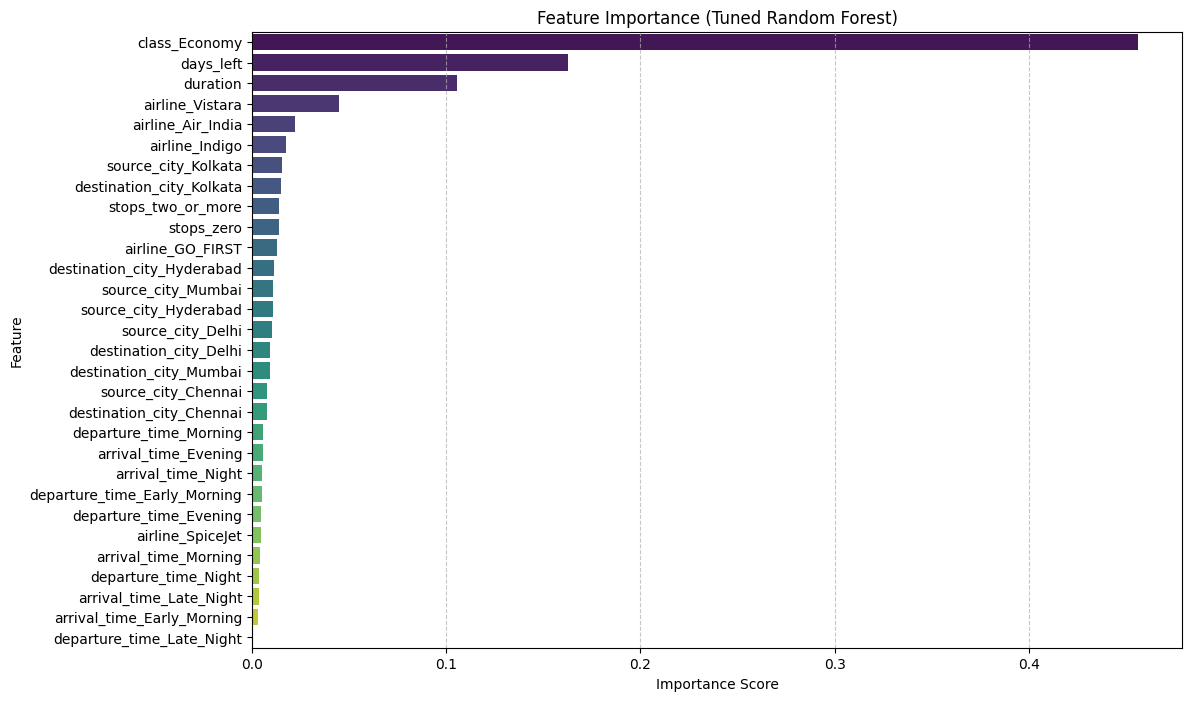

In [55]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_optimized, labels=train_labels)

# Print as table
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=train_labels, columns=train_labels))

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_labels, yticklabels=train_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Tuned Random Forest)')
plt.show()

# Get feature importances
importances = rf_optimized.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display as table for reference
print("\nFeature Importances:")
print(feature_importance_df)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance (Tuned Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


GENERATING LEARNING CURVE...


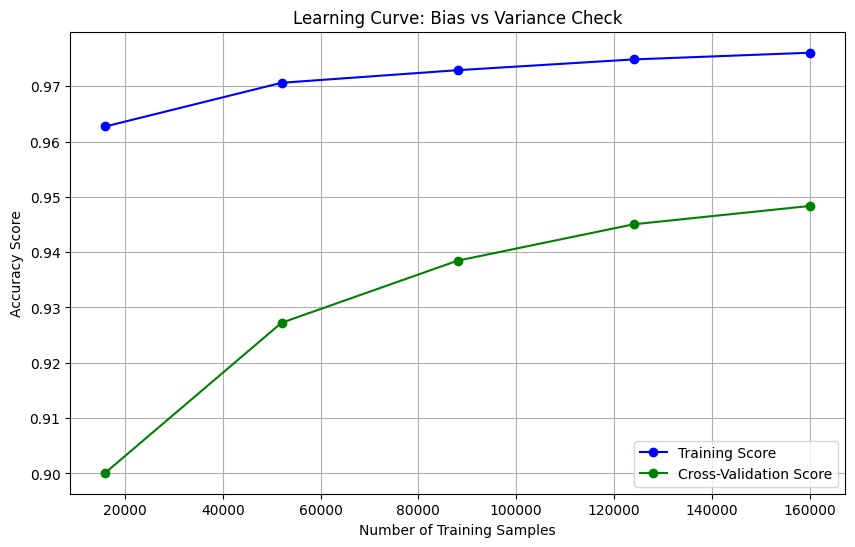


VISUALIZING TREE STRUCTURE...


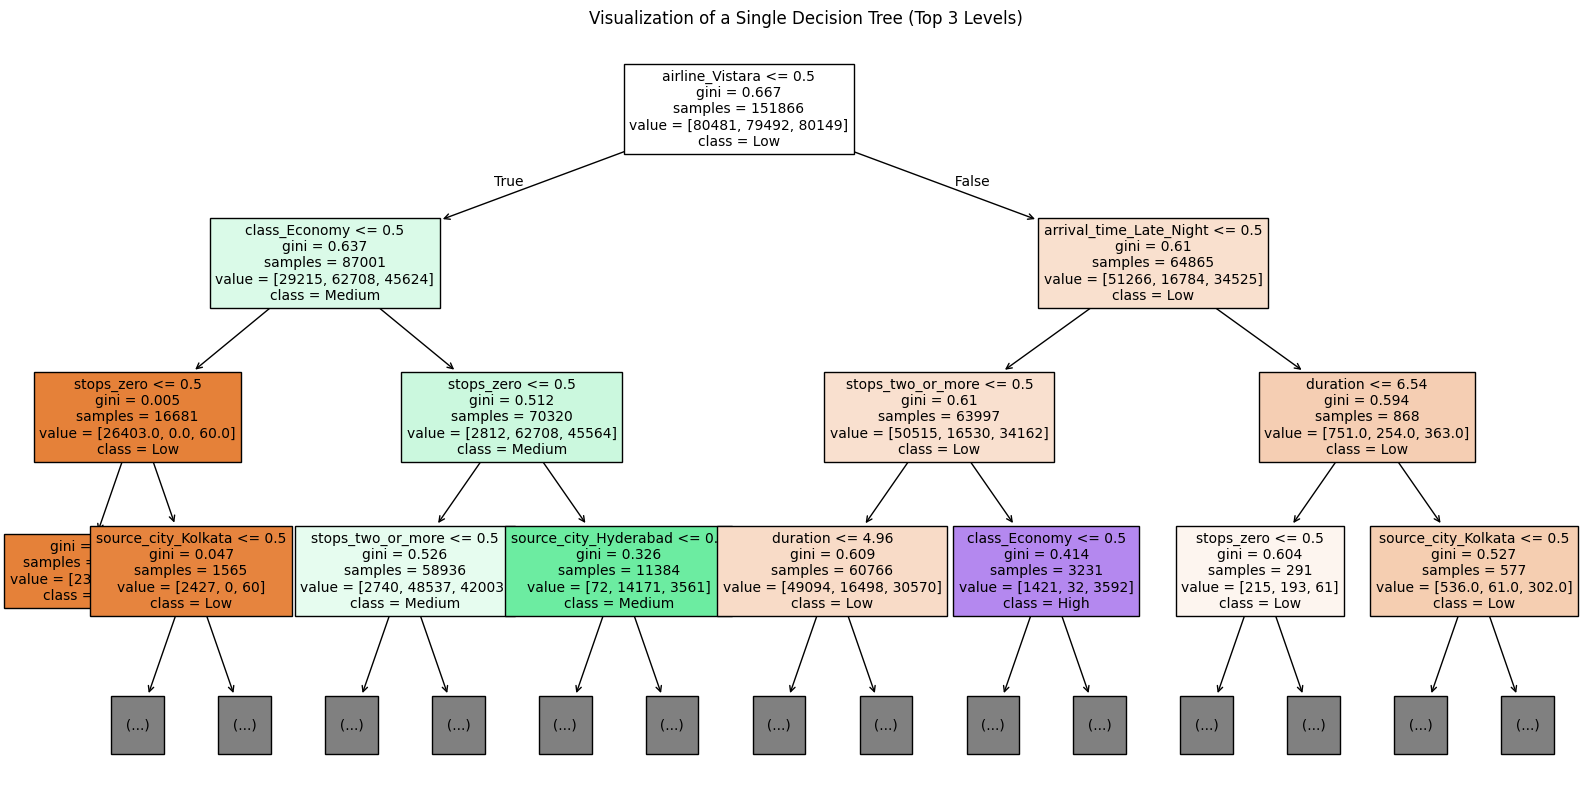

In [ ]:
print("\n" + "="*40)
print("GENERATING LEARNING CURVE...")
print("="*40)


train_sizes, train_scores, test_scores = learning_curve(
    rf_optimized, 
    X_train_final,  # <--- CORRECTED variable
    y_train, 
    cv=3, 
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue', marker='o')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='green', marker='o')

plt.title('Learning Curve: Bias vs Variance Check')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid()
plt.show()


# SINGLE TREE STRUCTURE

print("\n" + "="*40)
print("VISUALIZING TREE STRUCTURE...")
print("="*40)

# Visualizing one tree to explain the "Rules"
plt.figure(figsize=(20, 10))

plot_tree(rf_optimized.estimators_[0], 
          feature_names=X_train_final.columns,  
          class_names=['Low', 'Medium', 'High'], 
          filled=True, 
          max_depth=3,    
          fontsize=10)

plt.title('Visualization of a Single Decision Tree (Top 3 Levels)')
plt.show()

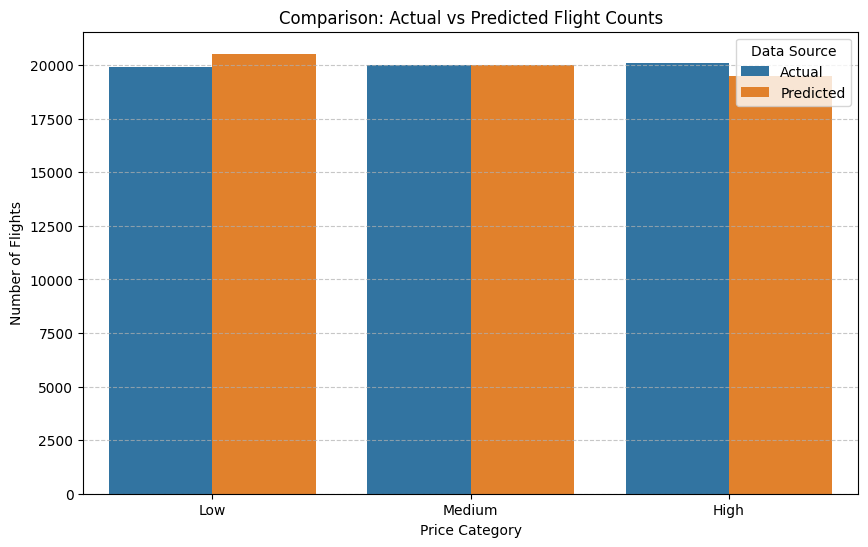

In [ ]:
results_df = pd.DataFrame({
    'Actual': y_test, 
    'Predicted': y_pred_optimized
})

results_melted = results_df.melt(var_name='Type', value_name='Category')

plt.figure(figsize=(10, 6))
sns.countplot(
    data=results_melted, 
    x='Category', 
    hue='Type', 
    order=['Low', 'Medium', 'High'], 
    palette=['#1f77b4', '#ff7f0e']
)
plt.title('Comparison: Actual vs Predicted Flight Counts')
plt.xlabel('Price Category')
plt.ylabel('Number of Flights')
plt.legend(title='Data Source')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()